# Self-Supervised Learning of Spatial Transcriptomics


This notebook demonstrates how to train a self supervised model on a collection of anndata objects and produce a "complete" checkpoint file.  

Here we are going to train the model for a short time just for demonstration.  

To reproduce the results in the paper run the scripts in the "run" folder.  

See documentation for more details.

## Common imports

In [1]:
import numpy
import torch
import seaborn
import tarfile
import os
import matplotlib
import matplotlib.pyplot as plt
from anndata import read_h5ad

# import tissue mosaic
import tissuemosaic as tm

In [2]:
## set seeds
import random
import numpy as np

r_seed=t_seed=n_seed=100

random.seed(r_seed)
torch.manual_seed(t_seed)
np.random.seed(n_seed)

In [3]:
import pytorch_lightning as pl
from pytorch_lightning.trainer import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint
from tissuemosaic.models import NeptuneLoggerCkpt
from tissuemosaic.data import AnndataFolderDM
from tissuemosaic.plots import show_raw_all_channels, show_raw_one_channel


## Read in and preprocess anndata

In [4]:
# Replace this with the path to where you have downloaded the data
data_destination_folder = os.path.abspath('../../TissueMosaic_Manuscript/TissueMosaic_data/testis_anndata/')

# Make a list of all the h5ad files in the data_destination_folder
fname_list = []
for f in os.listdir(data_destination_folder):
    if f.endswith('.h5ad'):
        fname_list.append(f)
print(fname_list)

['diabetes3_dm.h5ad', 'diabetes1_dm.h5ad', 'wt3_dm.h5ad', 'wt1_dm.h5ad', 'diabetes2_dm.h5ad', 'wt2_dm.h5ad']


In [5]:
# read in all the anndata

anndata_list = []
for fname in fname_list:
    try:
        anndata = read_h5ad(os.path.join(data_destination_folder, fname))
        print("Loaded {}".format(fname))
        anndata_list.append(anndata)
    except:
        pass

Loaded diabetes3_dm.h5ad
Loaded diabetes1_dm.h5ad
Loaded wt3_dm.h5ad
Loaded wt1_dm.h5ad
Loaded diabetes2_dm.h5ad
Loaded wt2_dm.h5ad


In [6]:
for i,anndata in enumerate(anndata_list):
    anndata.obs['cell_type'] = anndata.obsm['cell_type_proportions'].idxmax(axis=1)
    anndata.write_h5ad(os.path.join(data_destination_folder, fname_list[i]))

## Visualize anndata as a sanity check

In [7]:
anndata_list[0]

AnnData object with n_obs × n_vars = 34868 × 23536
    obs: 'x', 'y', 'UMI', 'cell_type'
    uns: 'status'
    obsm: 'cell_type_proportions'

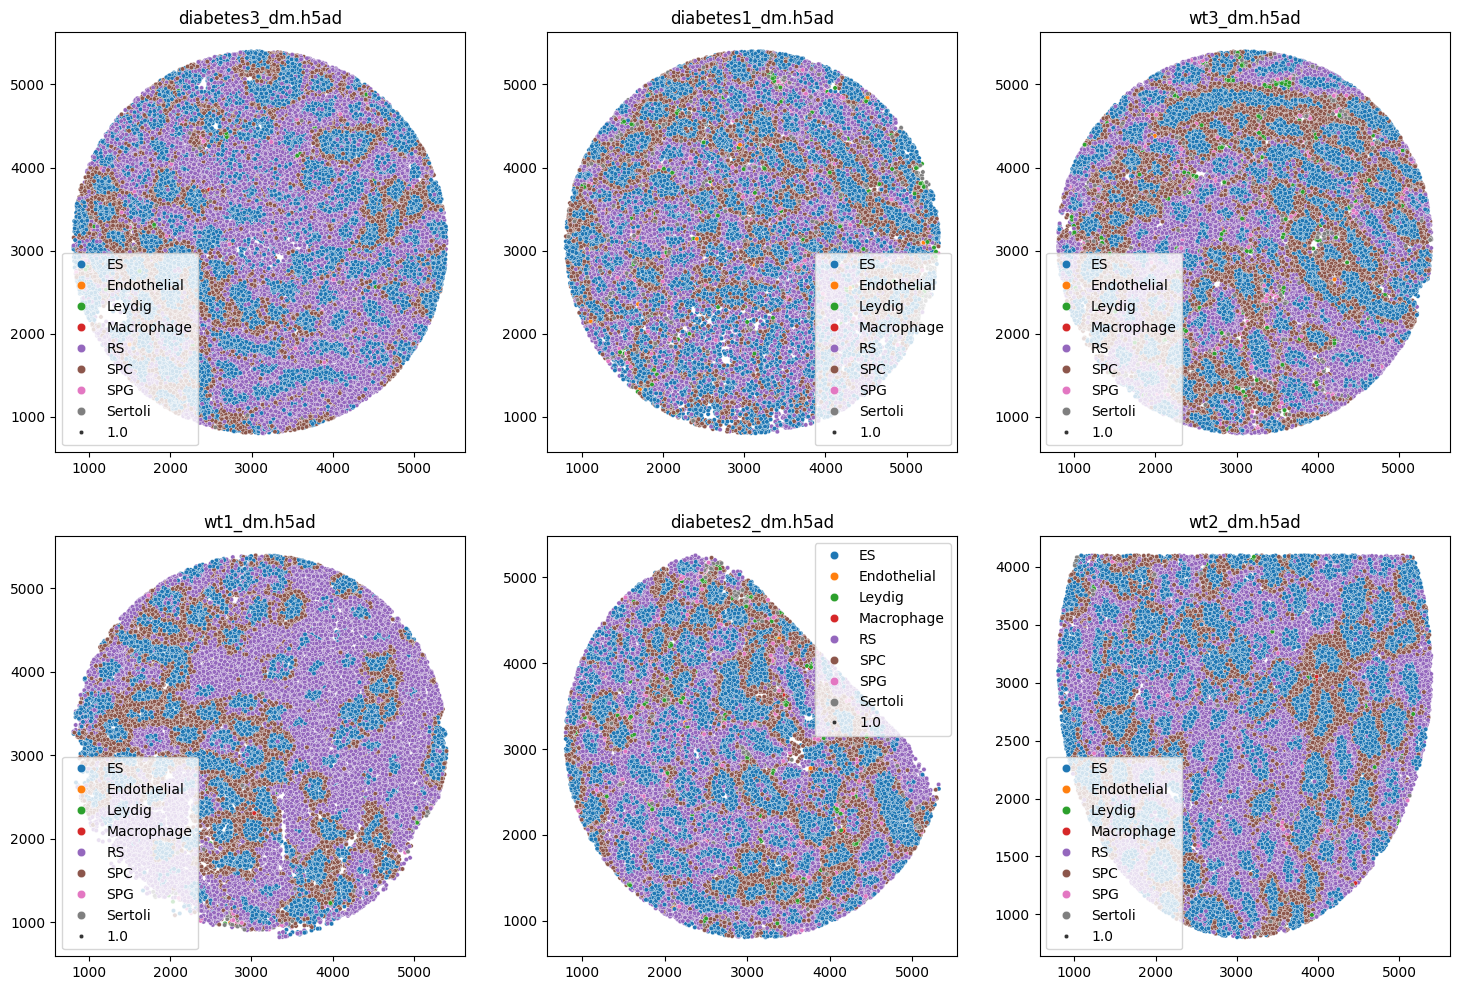

In [8]:
## Plot cell types in space

ncols=3
nrows=2
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(6*ncols,6*nrows))

# Define an consistent mapping from cell_type and color for all the plots
cell_types = numpy.asarray(anndata_list[0].obs['cell_type'].values)
unique_cell_types = numpy.unique(cell_types)

n = -1
for r in range(nrows):
    for c in range(ncols):
        n += 1
        anndata_tmp = anndata_list[n]
        cell_types = numpy.asarray(anndata_tmp.obs['cell_type'].values)
        x = numpy.asarray(anndata_tmp.obs['x'].values)
        y = numpy.asarray(anndata_tmp.obs['y'].values) 
        seaborn.scatterplot(x=x, y=y, hue=cell_types, ax=axes[r,c], size=numpy.ones_like(x), sizes=(10, 10), hue_order=unique_cell_types) 
        _ = axes[r,c].set_title(fname_list[n])

/tmp/ipykernel_636776/3217241272.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[r,c].set_xticklabels(labels=x_labels_raw, rotation=x_labels_rotation)
/tmp/ipykernel_636776/3217241272.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[r,c].set_xticklabels(labels=x_labels_raw, rotation=x_labels_rotation)
/tmp/ipykernel_636776/3217241272.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[r,c].set_xticklabels(labels=x_labels_raw, rotation=x_labels_rotation)
/tmp/ipykernel_636776/3217241272.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[r,c].set_xticklabels(labels=x_labels_raw, rotation=x_labels_rotation)
/tmp/ipykernel_63677

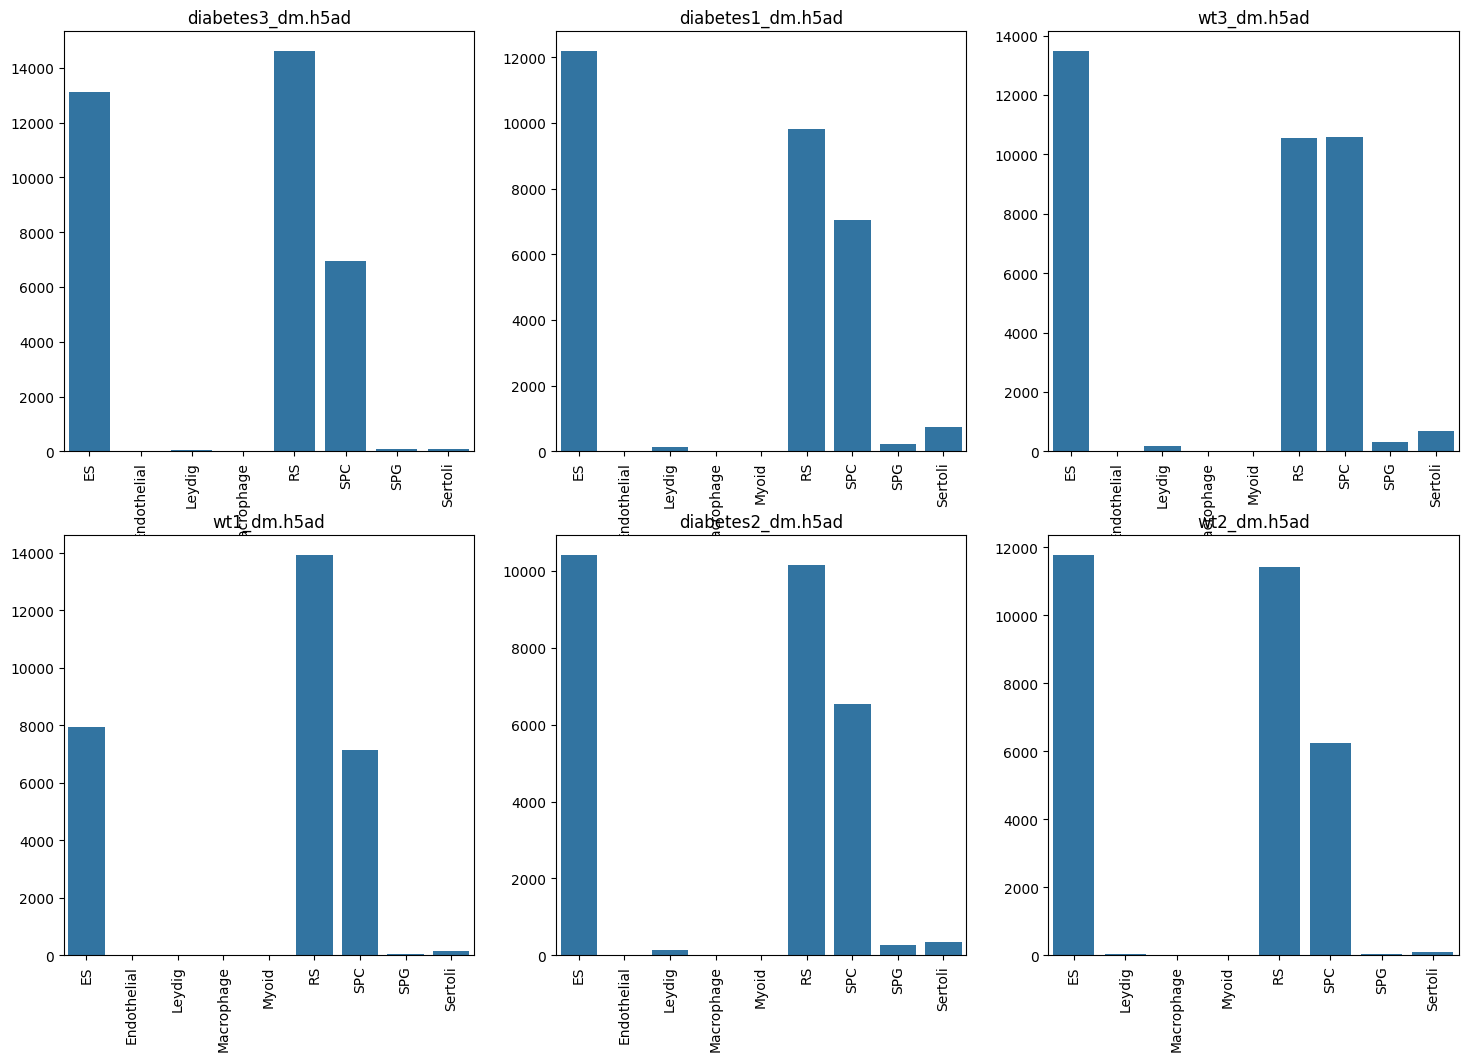

In [9]:
## Plot cell type distribution in each sample

x_labels_rotation = 90
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(6*ncols,6*nrows))
n = -1
for r in range(nrows):
    for c in range(ncols):
        n += 1
        counts = anndata_list[n].obs["cell_type"].value_counts(sort=False)
        x = numpy.asarray(counts.index)
        y = counts.to_numpy()
        _ = seaborn.barplot(x=x, y=y, ax=axes[r,c])
        x_labels_raw = axes[r,c].get_xticklabels()
        axes[r,c].set_xticklabels(labels=x_labels_raw, rotation=x_labels_rotation)
        _ = axes[r,c].set_title(fname_list[n])

## Instantiate DataModule 

Here we use the defaults parameters for the datamodule and only define:

1. The mapping from cell_type to channels in the image. Each channel will represent the density of a specific cell_type. In some situation it may make sense to map multiple cell-types to the same channel. For example CD4+ and CD4- cells might be mapped to the same channel.
2. The folder with the anndata h5ad files

In [10]:
# Load config from YAML file first to get the correct categories_to_channels
import yaml
with open('../run/config_dino_ssl_testis.yaml', 'r') as f:
    config_yaml = yaml.safe_load(f)

# Use the categories_to_channels from the YAML config 
categories_to_channels = config_yaml['categories_to_channels'].copy()

config_dm = tm.data.AnndataFolderDM.get_default_params() # get the defaults parameters
config_dm["data_folder"] = data_destination_folder  # specify the folder with the anndata h5ad files
config_dm["categories_to_channels"] = categories_to_channels  # specify the mapping between cell_types and channels
config_dm['category_key'] = 'cell_type_proportions' # specify which key in obsm contains input features

dm = tm.data.AnndataFolderDM(**config_dm)

## Instantiate the Model

Here we use Dino, but the same approach works for Barlow Twins, SimCLR, and VAE.

We use the defaults parameters and only change the number of input channels of the image.

In [11]:
from tissuemosaic.models.ssl_models import *
# now you can access: Barlow, Simclr, Dino, Vae

config_model = tm.models.ssl_models.Dino.get_default_params()  # get the default parameters

# Use the already loaded config_yaml from the previous cell
for key in config_yaml:
    config_model[key] = config_yaml[key]

config_model['image_in_ch'] = dm.ch_in  # specify the number of input channels consistently with datamodule

config_model.update(config_dm)  # concatenate the two configuration dictionaries
model = tm.models.ssl_models.Dino(**config_model)  
# Now the checkpoint contains the full information to reproduce the simulation.

/home/skambha6/miniforge3/envs/tissuemosaic_clone_clone_clone/lib/python3.11/site-packages/pl_bolts/__init__.py:11: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
/home/skambha6/miniforge3/envs/tissuemosaic_clone_clone_clone/lib/python3.11/site-packages/pl_bolts/__init__.py:11: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, tp_name):
/home/skambha6/miniforge3/envs/tissuemosaic_clone_clone_clone/lib/python3.11/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  "lr_options": generate_power_seq(

## Train the model and save the final checkpoint

We use Neptune to log our results.  

Here Neptune is run in the 'offline' mode and the logs are written to local disk.  

Neptune can run in 'async' mode and the results will be saved on a remote database with a nice graphic interface.  

For the 'async' option to work you need to sign up for a free account and provide the correct project and api_key.  

See https://docs.neptune.ai/ for more info.

In [12]:
pl_neptune_logger = NeptuneLoggerCkpt(
    api_key="ANONYMOUS",  # replace with your own
    project='cellarium/tissue-purifier', # replace with your own
    run=None,  # if None a new run will be logged. If the run is provided the result will be appended to existing run  
    log_model_checkpoints=True, 
    mode="offline",  # "async"
    tags=["test"],
    fail_on_exception=True,  
)

# Save the checkpoint periodically during training
ckpt_train = ModelCheckpoint(
    save_weights_only=False,
    save_on_train_epoch_end=True,
    save_last=True,
    every_n_epochs=5,
)
    
# Define the trainer
pl_trainer = Trainer(
    # weights_save_path="saved_ckpt",
    callbacks=[ckpt_train],
    gpus=1,#torch.cuda.device_count(),  # number of gpu cards on a single machine to use
    check_val_every_n_epoch=10,
    num_sanity_val_steps=0,
    max_epochs=5, #config_model["max_epochs"],  # run for a 5 epochs for demonstration
    logger=pl_neptune_logger,
    log_every_n_steps=100,
    sync_batchnorm=True,
    accelerator="auto",
    devices=1
)

/home/skambha6/miniforge3/envs/tissuemosaic_clone_clone_clone/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
/home/skambha6/miniforge3/envs/tissuemosaic_clone_clone_clone/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:498: UserWarning: The flag `devices=1` will be ignored, instead the device specific number 1 will be used
  rank_zero_warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [13]:
# Fit the model to the data. 
# To obtain the best results, run till loss has converged (increase 'max_epochs' in the previous cell). 
# This will typically be easier to do from command line, following run/main_1_train_ssl.py
pl_trainer.fit(model=model, datamodule=dm)

reading file /seagate_mnt/tissue_purifier/TissueMosaic_Manuscript/TissueMosaic_data/testis_anndata/diabetes3_dm.h5ad
number of elements ---> 34868
mean and median spacing 15.821949004591055, 15.638433550603624
The dense shape of the image is -> torch.Size([9, 1180, 1181])
reading file /seagate_mnt/tissue_purifier/TissueMosaic_Manuscript/TissueMosaic_data/testis_anndata/diabetes1_dm.h5ad
number of elements ---> 30132
mean and median spacing 16.353857684013548, 15.931447916615909
The dense shape of the image is -> torch.Size([9, 1180, 1180])
reading file /seagate_mnt/tissue_purifier/TissueMosaic_Manuscript/TissueMosaic_data/testis_anndata/wt3_dm.h5ad
number of elements ---> 35797
mean and median spacing 15.760547246990356, 15.570735462452099
The dense shape of the image is -> torch.Size([9, 1179, 1180])
reading file /seagate_mnt/tissue_purifier/TissueMosaic_Manuscript/TissueMosaic_data/testis_anndata/wt1_dm.h5ad
number of elements ---> 29178
mean and median spacing 15.90507495709278, 15.

You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


saved the file /seagate_mnt/tissue_purifier/TissueMosaic_Manuscript/TissueMosaic_data/testis_anndata/test_dataset.pt


/home/skambha6/miniforge3/envs/tissuemosaic_clone_clone_clone/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:613: UserWarning: Checkpoint directory /seagate_mnt/tissue_purifier/TissueMosaic/notebooks/.neptune/None/version_None/checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name    | Type               | Params
-----------------------------------------------
0 | student | MultiResolutionNet | 21.8 M
1 | teacher | MultiResolutionNet | 21.8 M
-----------------------------------------------
21.8 M    Trainable params
21.8 M    Non-trainable params
43.6 M    Total params
174.454   Total estimated model params size (MB)


read the file /seagate_mnt/tissue_purifier/TissueMosaic_Manuscript/TissueMosaic_data/testis_anndata/train_dataset.pt
All cat_to_codes dictionaries are identical {'ES': 0, 'Endothelial': 1, 'Leydig': 2, 'Macrophage': 3, 'Myoid': 4, 'RS': 5, 'SPC': 6, 'SPG': 7, 'Sertoli': 8}
created train_dataset device = cpu, length = 12
read the file /seagate_mnt/tissue_purifier/TissueMosaic_Manuscript/TissueMosaic_data/testis_anndata/test_dataset.pt
created test_dataset device = cpu, length = 300
[neptune] [info   ] Neptune initialized. Open in the app: offline/44c6cf73-a7b2-40db-94c6-c067b309b026


...

Training: 0it [00:00, ?it/s]

/home/skambha6/miniforge3/envs/tissuemosaic_clone_clone_clone/lib/python3.11/site-packages/pytorch_lightning/utilities/data.py:83: UserWarning: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 9. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
  warning_cache.warn(


NOT copied ckpt file /seagate_mnt/tissue_purifier/TissueMosaic/notebooks/.neptune/None/version_None/checkpoints/last-v4.ckpt to /cromwell_root/my_checkpoint.ckpt b/c destination don't exist
NOT copied ckpt file /seagate_mnt/tissue_purifier/TissueMosaic/notebooks/.neptune/None/version_None/checkpoints/last-v4.ckpt to /cromwell_root/my_checkpoint.ckpt b/c destination don't exist
NOT copied ckpt file /seagate_mnt/tissue_purifier/TissueMosaic/notebooks/.neptune/None/version_None/checkpoints/last-v4.ckpt to /cromwell_root/my_checkpoint.ckpt b/c destination don't exist
NOT copied ckpt file /seagate_mnt/tissue_purifier/TissueMosaic/notebooks/.neptune/None/version_None/checkpoints/last-v4.ckpt to /cromwell_root/my_checkpoint.ckpt b/c destination don't exist
NOT copied ckpt file /seagate_mnt/tissue_purifier/TissueMosaic/notebooks/.neptune/None/version_None/checkpoints/epoch=4-step=30-v2.ckpt to /cromwell_root/my_checkpoint.ckpt b/c destination don't exist


`Trainer.fit` stopped: `max_epochs=5` reached.


NOT copied ckpt file /seagate_mnt/tissue_purifier/TissueMosaic/notebooks/.neptune/None/version_None/checkpoints/last-v4.ckpt to /cromwell_root/my_checkpoint.ckpt b/c destination don't exist


## Save checkpoint

Since the model was instantiate using a dictionary containing all the parameters (both for model and datamodule) the checkpoint is complete.  

A single checkpoint file contains all the information needded to reproduce the simulation.

In [14]:
pl_trainer.save_checkpoint("ckpt_dino_ssl.pt")  

## Visualize the crops used for training as a sanity check

In [15]:
train_loader = dm.train_dataloader()  # get the train_dataloader from the datamodule
batch = next(iter(train_loader))  # get one batch from the dataloader
list_sp_imgs, list_labels, list_metadata = batch  # batch consists of 3 lists: sparse_images, labels, metadata

In [16]:
n_examples = 5  # number of distinct crops
n_augmentations = 3  # apply the random data augmentation this many times

all_imgs = []
for n in range(n_augmentations):
    imgs_tmp = dm.trsfm_train_global(list_sp_imgs[:n_examples])  # apply the data augmentations
    all_imgs.append(imgs_tmp)
    
imgs_train = torch.cat(all_imgs, dim=0)
print("imgs_train.shape ->", imgs_train.shape)

imgs_train.shape -> torch.Size([15, 9, 96, 96])


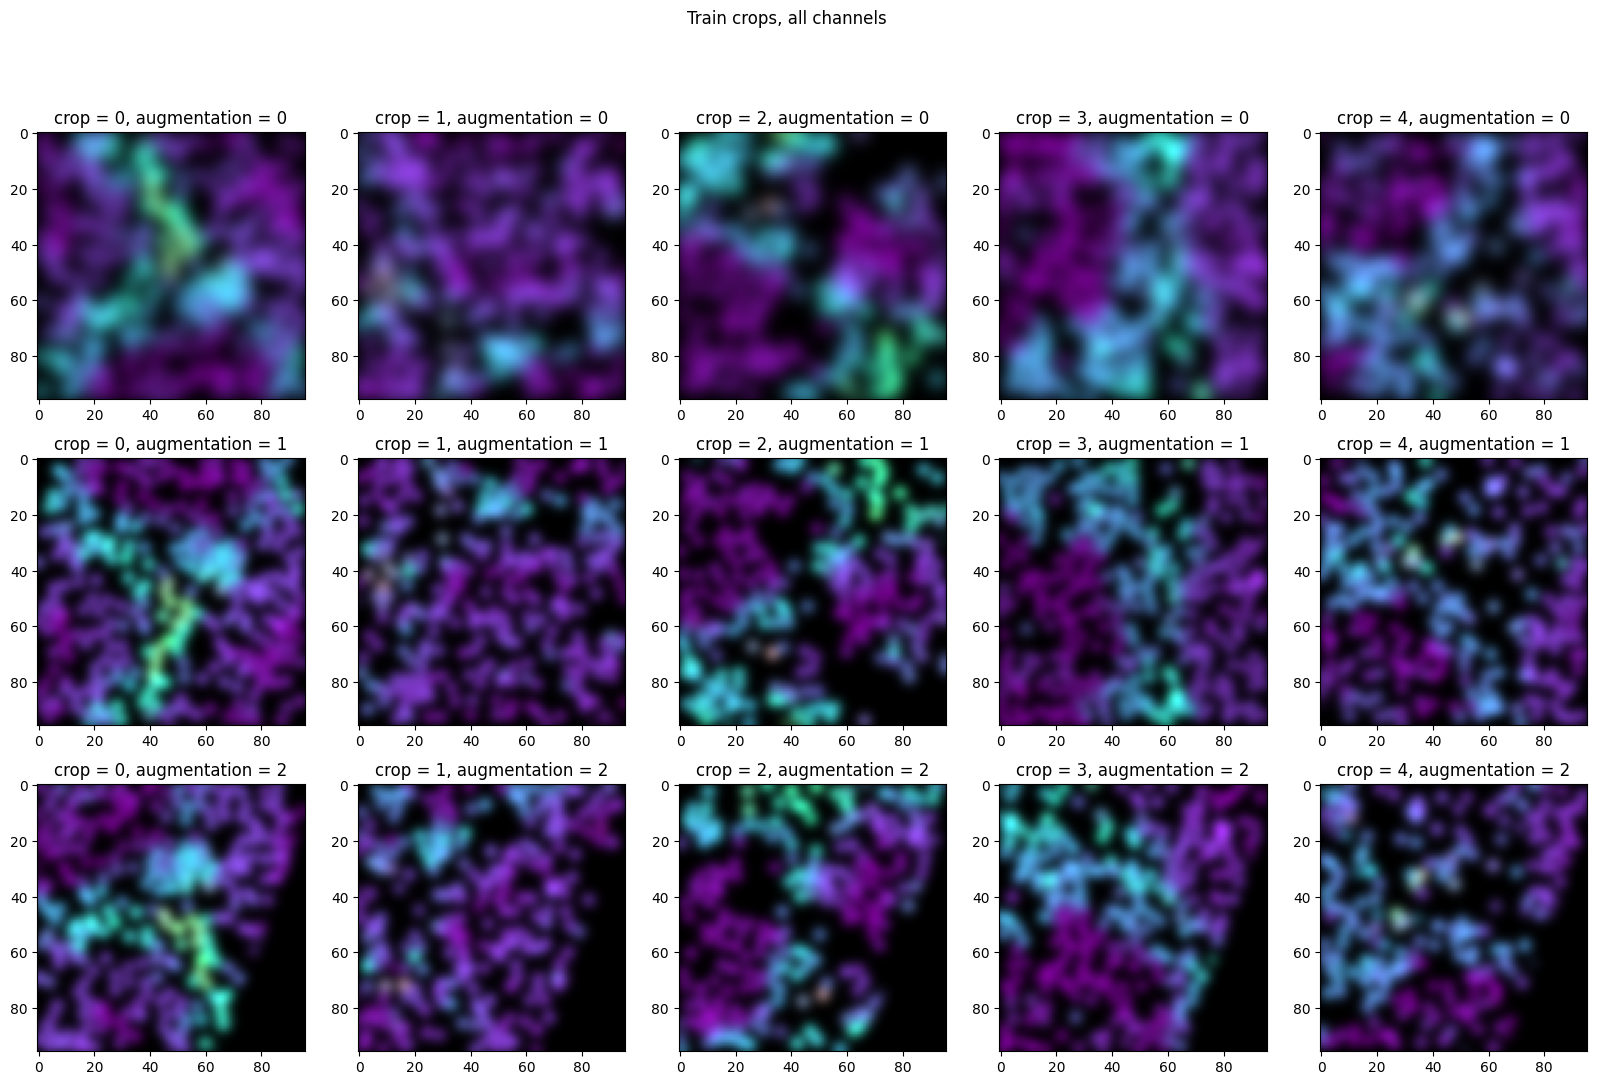

In [17]:
# Each column is a different patch
# Each row is a different instance of the random data-augmentation

titles = []
for r in range(n_augmentations):
    for c in range(n_examples):
        titles.append("crop = {}, augmentation = {}".format(c,r))

train_all_ch_fig = show_raw_all_channels(imgs_train, 
                                         cmap="viridis", 
                                         n_col=n_examples, 
                                         figsize=(4*n_examples, 4*n_augmentations), 
                                         sup_title="Train crops, all channels",
                                        titles=titles)
train_all_ch_fig